<h1>Credit Risk Modelling</h1>

<h3>Problem Statement</h3>

Lauki Finance currently faces a massive operational bottleneck due to its manual evaluation of credit scores and loan applications. This time-consuming process severely limits the number of customers the company can efficiently serve. To address this issue, there is a critical need to develop an automated, machine learning-driven credit risk model and scoring system that can instantly assess default probabilities and categorize loan applications. Implementing this automated solution will streamline the credit evaluation lifecycle, enabling Lauki Finance to make faster, data-backed lending decisions while eliminating the manual workload.

<h3>Importing required libraries</h3>

In [1]:
import joblib 
import optuna
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from imblearn.combine import SMOTETomek
from pandas.api.types import is_numeric_dtype
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import classification_report, make_scorer, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

C:\Users\SRIJIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.float_format', lambda x: '%.3f' %x)
np.set_printoptions(suppress = True)

<h3>Loading data and understanding</h3>

In [3]:
df_customers = pd.read_csv("data/customers.csv")
df_loans = pd.read_csv("data/loans.csv")
df_bureau = pd.read_csv("data/bureau_data.csv")

In [4]:
print(f"Customers dataset: {df_customers.shape} \nLoans dataset: {df_loans.shape} \nBureau dataset: {df_bureau.shape}")

Customers dataset: (50000, 12) 
Loans dataset: (50000, 15) 
Bureau dataset: (50000, 8)


In [5]:
df_customers.head(1)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001


In [6]:
df_loans.head(1)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False


In [7]:
df_bureau.head(1)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7


In [8]:
df = pd.merge(df_customers, df_loans, on = "cust_id")
df = df.merge(df_bureau, on = "cust_id")
print(f"Fist merged dataset size: {df.shape}")
df.head(1)

Fist merged dataset size: (50000, 33)


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  str    
 13  loan_purpose               

Based on the merged dataset profile, Lauki Finance has a highly complete dataset of 50,000 historical loan applications containing 26 key demographic and financial attributes. With almost no missing data—save for a negligible 62 missing entries in the residence_type column—this dataset provides a robust mix of categorical and numerical features ready for engineering to predict the default target variable and automate lending decisions.

<h3>Class imbalance and early splitting</h3>

We can see that our target column, 'default', is boolean. We need to convert it to integers for our machine learning model.

In [10]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

We clearly see a class imbalance. For our default cases (1), we have less than 9% of the total records. Because of this, we will use 'stratify=y' when splitting our data to ensure both train and test sets have the same proportion of default cases.

In [11]:
x = df.drop('default', axis = 'columns')
y = df['default']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, stratify = y, random_state = 42)

Notice that we are splitting the data right now, before doing any data cleaning or feature engineering. We are doing this early split to prevent a major issue: Data Leakage.

Following this workflow, we will now combine our x_train and y_train back together temporarily so we can safely perform our Exploratory Data Analysis without looking at the test data.

In [13]:
df_train = pd.concat([x_train, y_train], axis = "columns")
df_test = pd.concat([x_test, y_test], axis = "columns")

<h3>Handling missing values (imputation)</h3>

In [14]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [15]:
df_train.residence_type.unique()

<ArrowStringArray>
['Owned', 'Mortgage', 'Rented', nan]
Length: 4, dtype: str

In [16]:
df_train.shape

(37500, 33)

Our training set has 37,500 rows. In the industry, if you have 2,000 to 3,000 null values, you have to think carefully about how to handle them. With only 47, it is mathematically safe to just drop those rows. 

Instead of dropping them, we will impute (fill) the missing values using the mode (the most frequent value) of that column.

In [17]:
train_residence_mode = df_train.residence_type.mode()[0]
test_residence_mode = df_test.residence_type.mode()[0]

In [18]:
df_train.fillna({"residence_type" : train_residence_mode}, inplace = True)
df_test.fillna({"residence_type" : test_residence_mode}, inplace = True)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,...,2021-06-24,2021-07-23,2,1,42,0,0,5,98,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,...,2021-02-09,2021-02-18,4,0,125,0,0,5,32,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,...,2022-08-06,2022-08-21,3,0,76,0,0,6,82,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,...,2023-02-03,2023-02-04,4,2,125,3,21,7,48,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,...,2023-09-27,2023-10-17,3,1,131,14,89,8,97,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,...,2022-06-28,2022-06-30,3,0,104,5,14,8,52,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,...,2021-08-13,2021-08-23,1,1,10,0,0,5,5,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,...,2019-08-18,2019-09-16,2,2,32,2,7,4,54,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,...,2022-12-05,2022-12-17,1,0,36,0,0,4,85,0


In [19]:
df_train.residence_type.unique()

<ArrowStringArray>
['Owned', 'Mortgage', 'Rented']
Length: 3, dtype: str

<h4>Checking for duplicates</h4>

Next, we quickly verify there are no duplicate rows in our dataset.

In [20]:
df_train.duplicated().sum()

np.int64(0)

In [21]:
df_test.duplicated().sum()

np.int64(0)

<h3>Outlier Detection (visualization)</h3>

We need to separate our continuous (numerical) columns from our categorical (text) columns to visualize them properly.

In [22]:
numerical_cols = df_train.drop(["default", "zipcode"], axis = "columns").select_dtypes(["int64", "float64"]).columns
categorical_cols = df_train.drop(["cust_id", "loan_id", "disbursal_date", "installment_start_dt"], axis = "columns").select_dtypes("str").columns

In [23]:
numerical_cols = np.array((numerical_cols))
categorical_cols = np.array(list(categorical_cols) + ["default", "zipcode"])

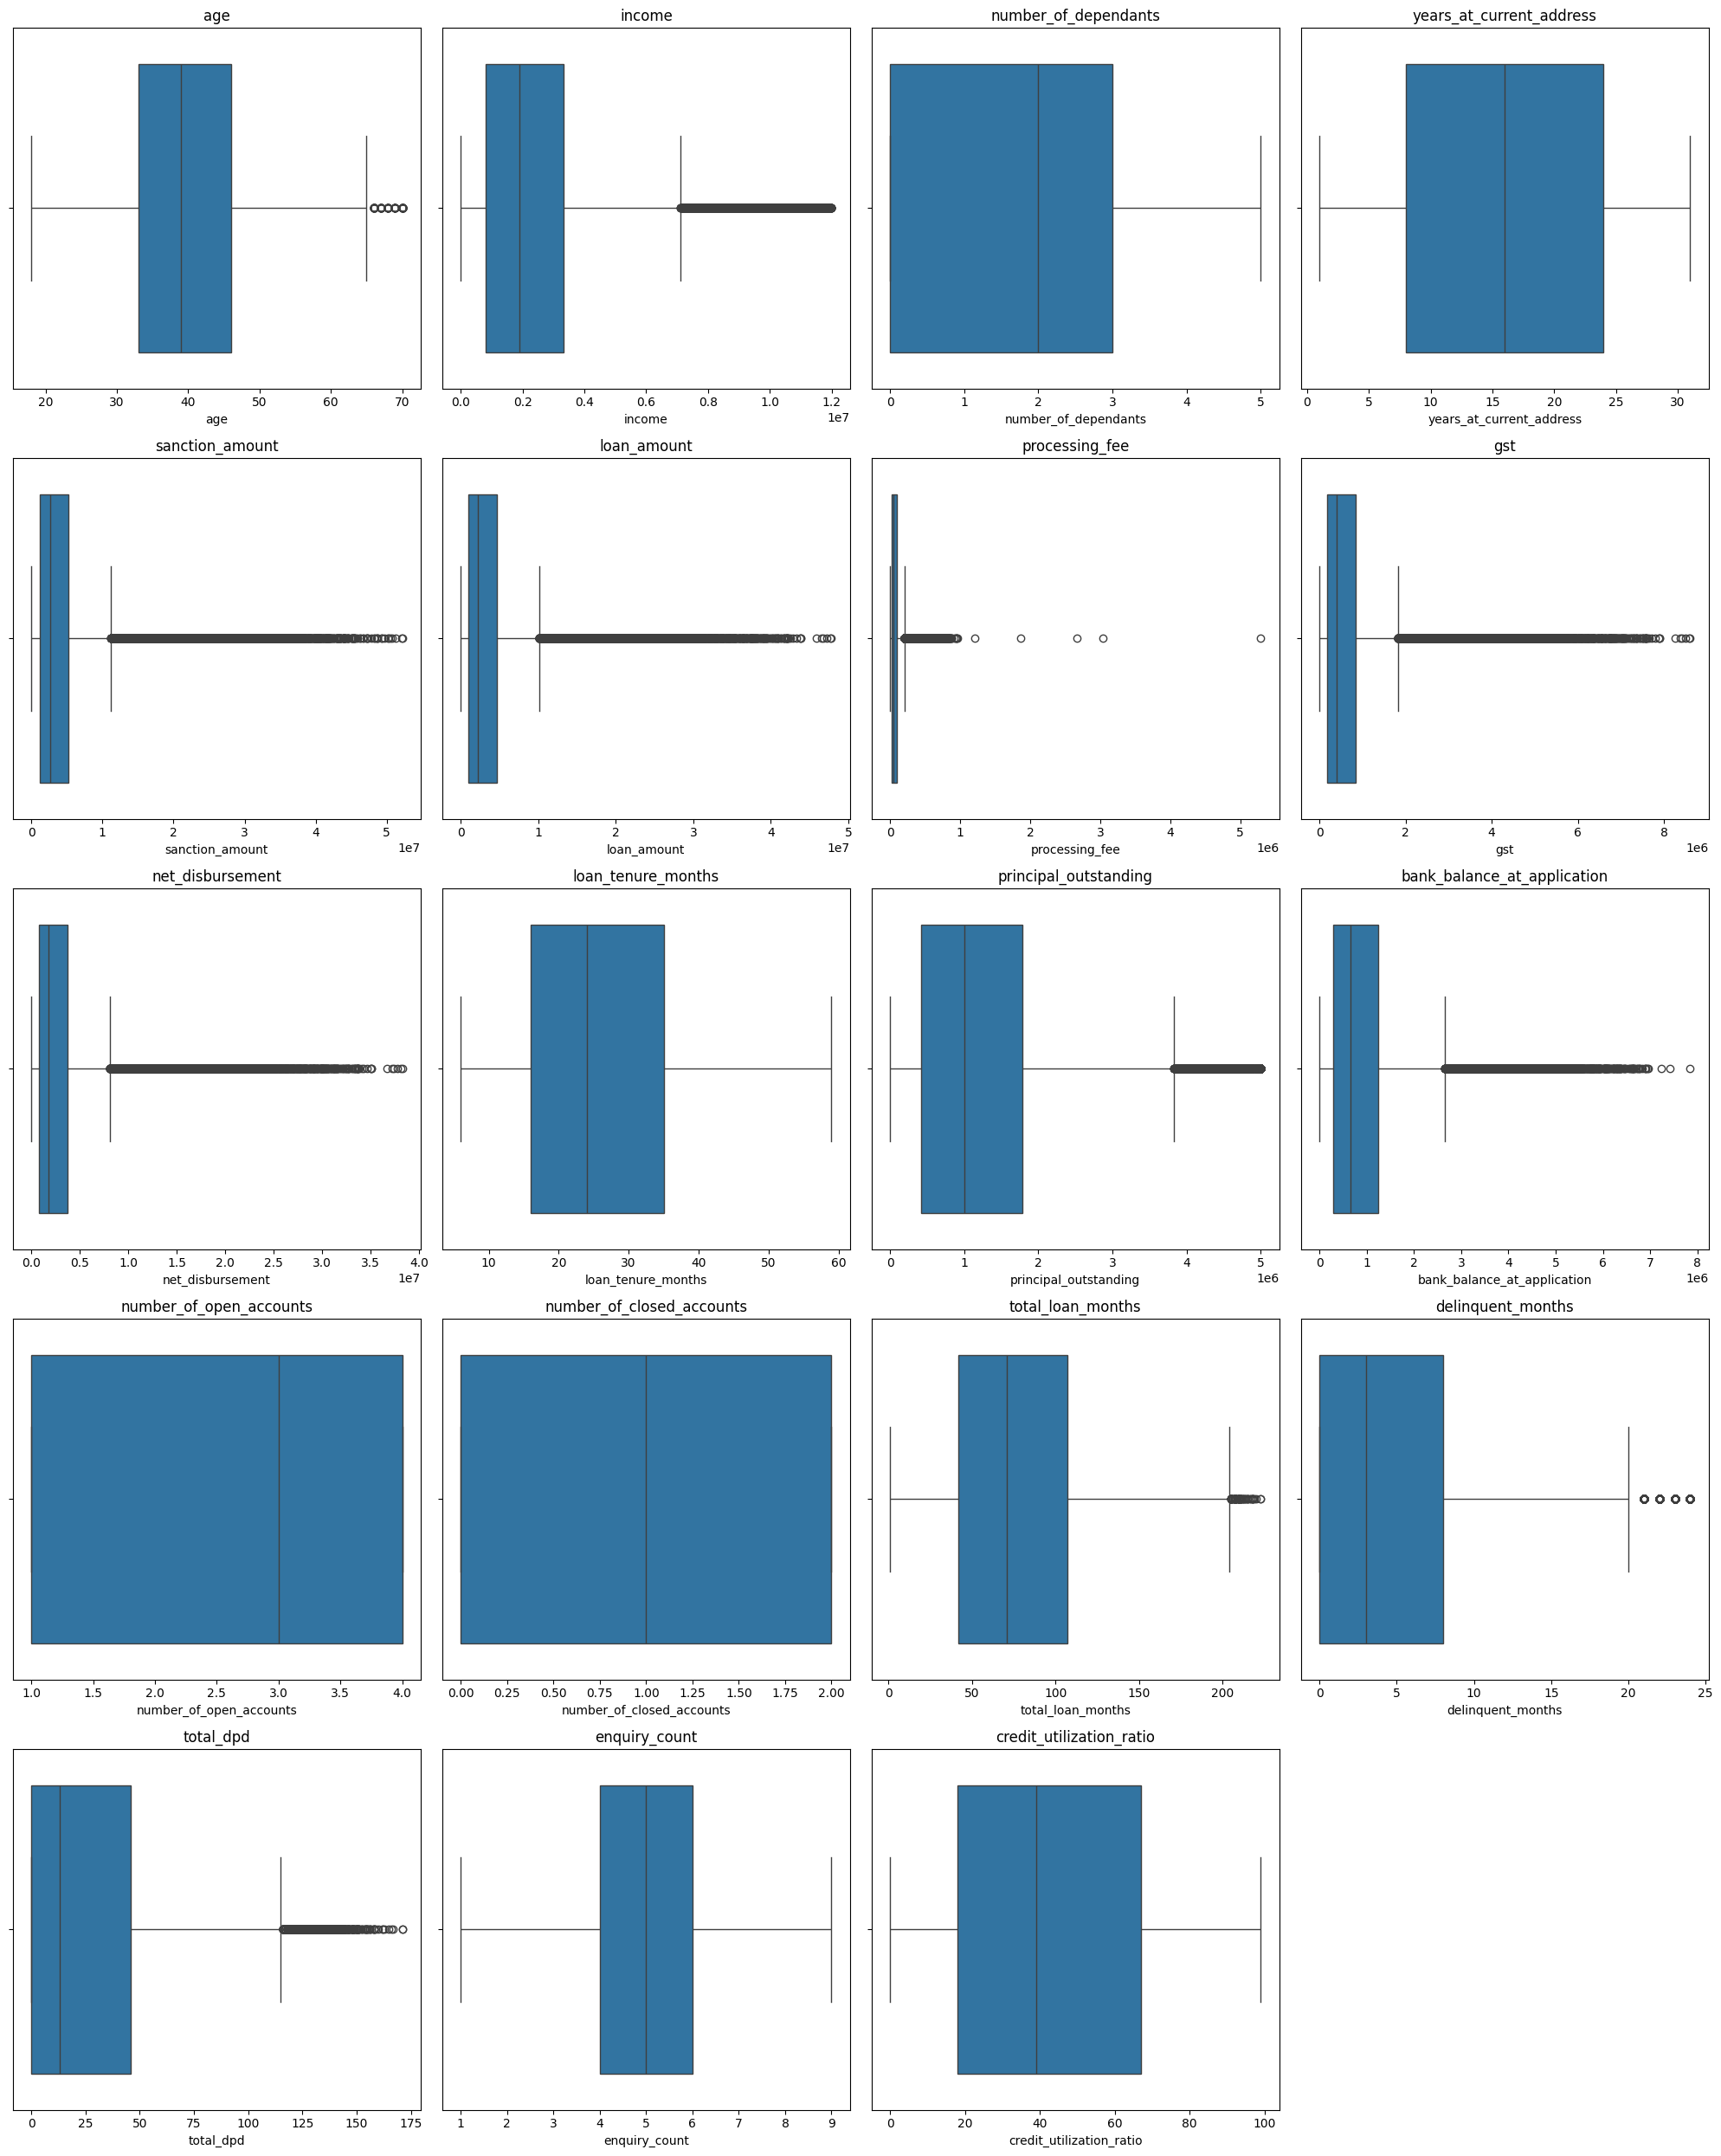

In [24]:
num_plots = len(numerical_cols)
num_cols = 4
num_rows = (num_plots + num_cols - 1)//num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize = (5*num_cols, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x = df_train[col], ax = axes[i])
    axes[i].set_title(col)

for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

* **Contextualizing Outliers:** As seen with age peaking around 70, statistical outliers do not always equate to data errors; a 70-year-old applying for a loan is a valid customer segment, meaning we must evaluate outliers through a business lens before removing them.

* **Income and Wealth Distribution:** The dense clusters of outliers in financial metrics like income and sanction_amount reflect natural economic realities—high-net-worth individuals or massive loans are statistically rare but represent highly profitable, legitimate business.

* **Integrity of Logical Boundaries:** Demographic features like number_of_dependants (capped around 5) and years_at_current_address (maxing out around 30) hit reasonable real-world ceilings, indicating strong data entry integrity with no nonsensical typos.

* **Crucial Risk Indicators:** Extreme values in credit bureau features—such as severe spikes in total_dpd (Days Past Due) or delinquent_months—appear as massive statistical anomalies but are the exact high-risk behaviors our model needs to memorize to predict defaults.

* **Actionable Treatment Strategy:** Because these extremes represent genuine business scenarios rather than noise, dropping them would mean discarding valuable customer data; instead, we should rely on robust scaling techniques or tree-based algorithms that handle skewed, real-world distributions natively.

Next, we look at the distributions using histograms. We notice that columns related to fees (processing_fee, gst) are heavily skewed, indicating a potential problem.

<h4>Investigating anomalies with business logic</h4>
Let's dig into the 'processing_fee' column.

In [25]:
df_train.processing_fee.describe()

count     37500.000
mean      80290.677
std      113128.140
min           0.000
25%       19220.000
50%       44600.000
75%       92420.000
max     5293543.524
Name: processing_fee, dtype: float64

We notice the maximum processing fee is a staggering 5,293,543. Let's look at the specific record to see the context.

In [26]:
df_train[df_train.processing_fee == df_train.processing_fee.max()][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
9898,3626000,5293543.524


We have a record where the customer took a loan of 3.62 million, but paid 5.29 million just in processing fees! This is impossible. No one pays more in fees than the actual loan amount. This is a clear data engineering error or a system glitch.

Let's see how many records have a processing fee higher than the loan amount:

In [27]:
df_train[df_train.processing_fee > df_train.loan_amount][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.023
28174,966000,1214492.673
47089,1738000,1858964.768
29305,2616000,3036378.005
9898,3626000,5293543.524


We found 7 such broken records. After consulting with domain experts, we established a rule: standard processing fees should never exceed 3% of the total loan amount.

We will filter our dataset to only keep valid records where the ratio is less than 0.03, we must apply this exact same cleaning step to our test set so it mirrors production expectations.

In [28]:
df_train_1 = df_train[(df_train.processing_fee/df_train.loan_amount) < 0.03].copy()
df_test = df_test[(df_test.processing_fee/df_test.loan_amount) < 0.03].copy()

We should also check other financial columns like GST to ensure data integrity. Using domain knowledge, GST is usually around 18%. We can set a safe threshold of 20% to check for data entry errors.

In [29]:
print("Train set: ",df_train[(df_train.gst/df_train.loan_amount) > 0.2].shape)
print("Test set: ",df_test[(df_test.gst/df_train.loan_amount) > 0.2].shape)

Train set:  (0, 33)
Test set:  (0, 33)


C:\Users\SRIJIT\AppData\Local\Temp\ipykernel_19364\3840591233.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("Test set: ",df_test[(df_test.gst/df_train.loan_amount) > 0.2].shape)


This code returns no records, which means our GST data looks clean.

<h4>Cleaning categorical variables (typos)</h4>

Finally, we loop through our categorical columns to check for spelling mistakes or inconsistent naming.

In [30]:
for col in categorical_cols:
    print(f"{col} ===> {np.array(df_train[col].unique())}")
    print("-" * 150)

gender ===> ['M' 'F']
------------------------------------------------------------------------------------------------------------------------------------------------------
marital_status ===> ['Married' 'Single']
------------------------------------------------------------------------------------------------------------------------------------------------------
employment_status ===> ['Self-Employed' 'Salaried']
------------------------------------------------------------------------------------------------------------------------------------------------------
residence_type ===> ['Owned' 'Mortgage' 'Rented']
------------------------------------------------------------------------------------------------------------------------------------------------------
city ===> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
-----------------------------------------------------------------------------------------------------------------------

In the 'loan_purpose' column, we spot a clear typo: we have both 'Personal' and 'Personaal'. We must consolidate these. Again, we do this for both train and test sets.

In [31]:
df_train_1["loan_purpose"] = df_train_1["loan_purpose"].replace("Personaal", "Personal")
df_test["loan_purpose"] = df_test["loan_purpose"].replace("Personaal", "Personal")

In [32]:
print(df_train_1["loan_purpose"].unique())

<ArrowStringArray>
['Home', 'Education', 'Personal', 'Auto']
Length: 4, dtype: str


<h2>Exploratory Data Analysis</h2>

<h3>Bivariate analysis with kdeplots</h3>
Next, we need to understand how our continuous features relate to our target variable ('default'). A great way to visualize this is using KDE (Kernel Density Estimate) plots, which show the smoothed distribution of the data.

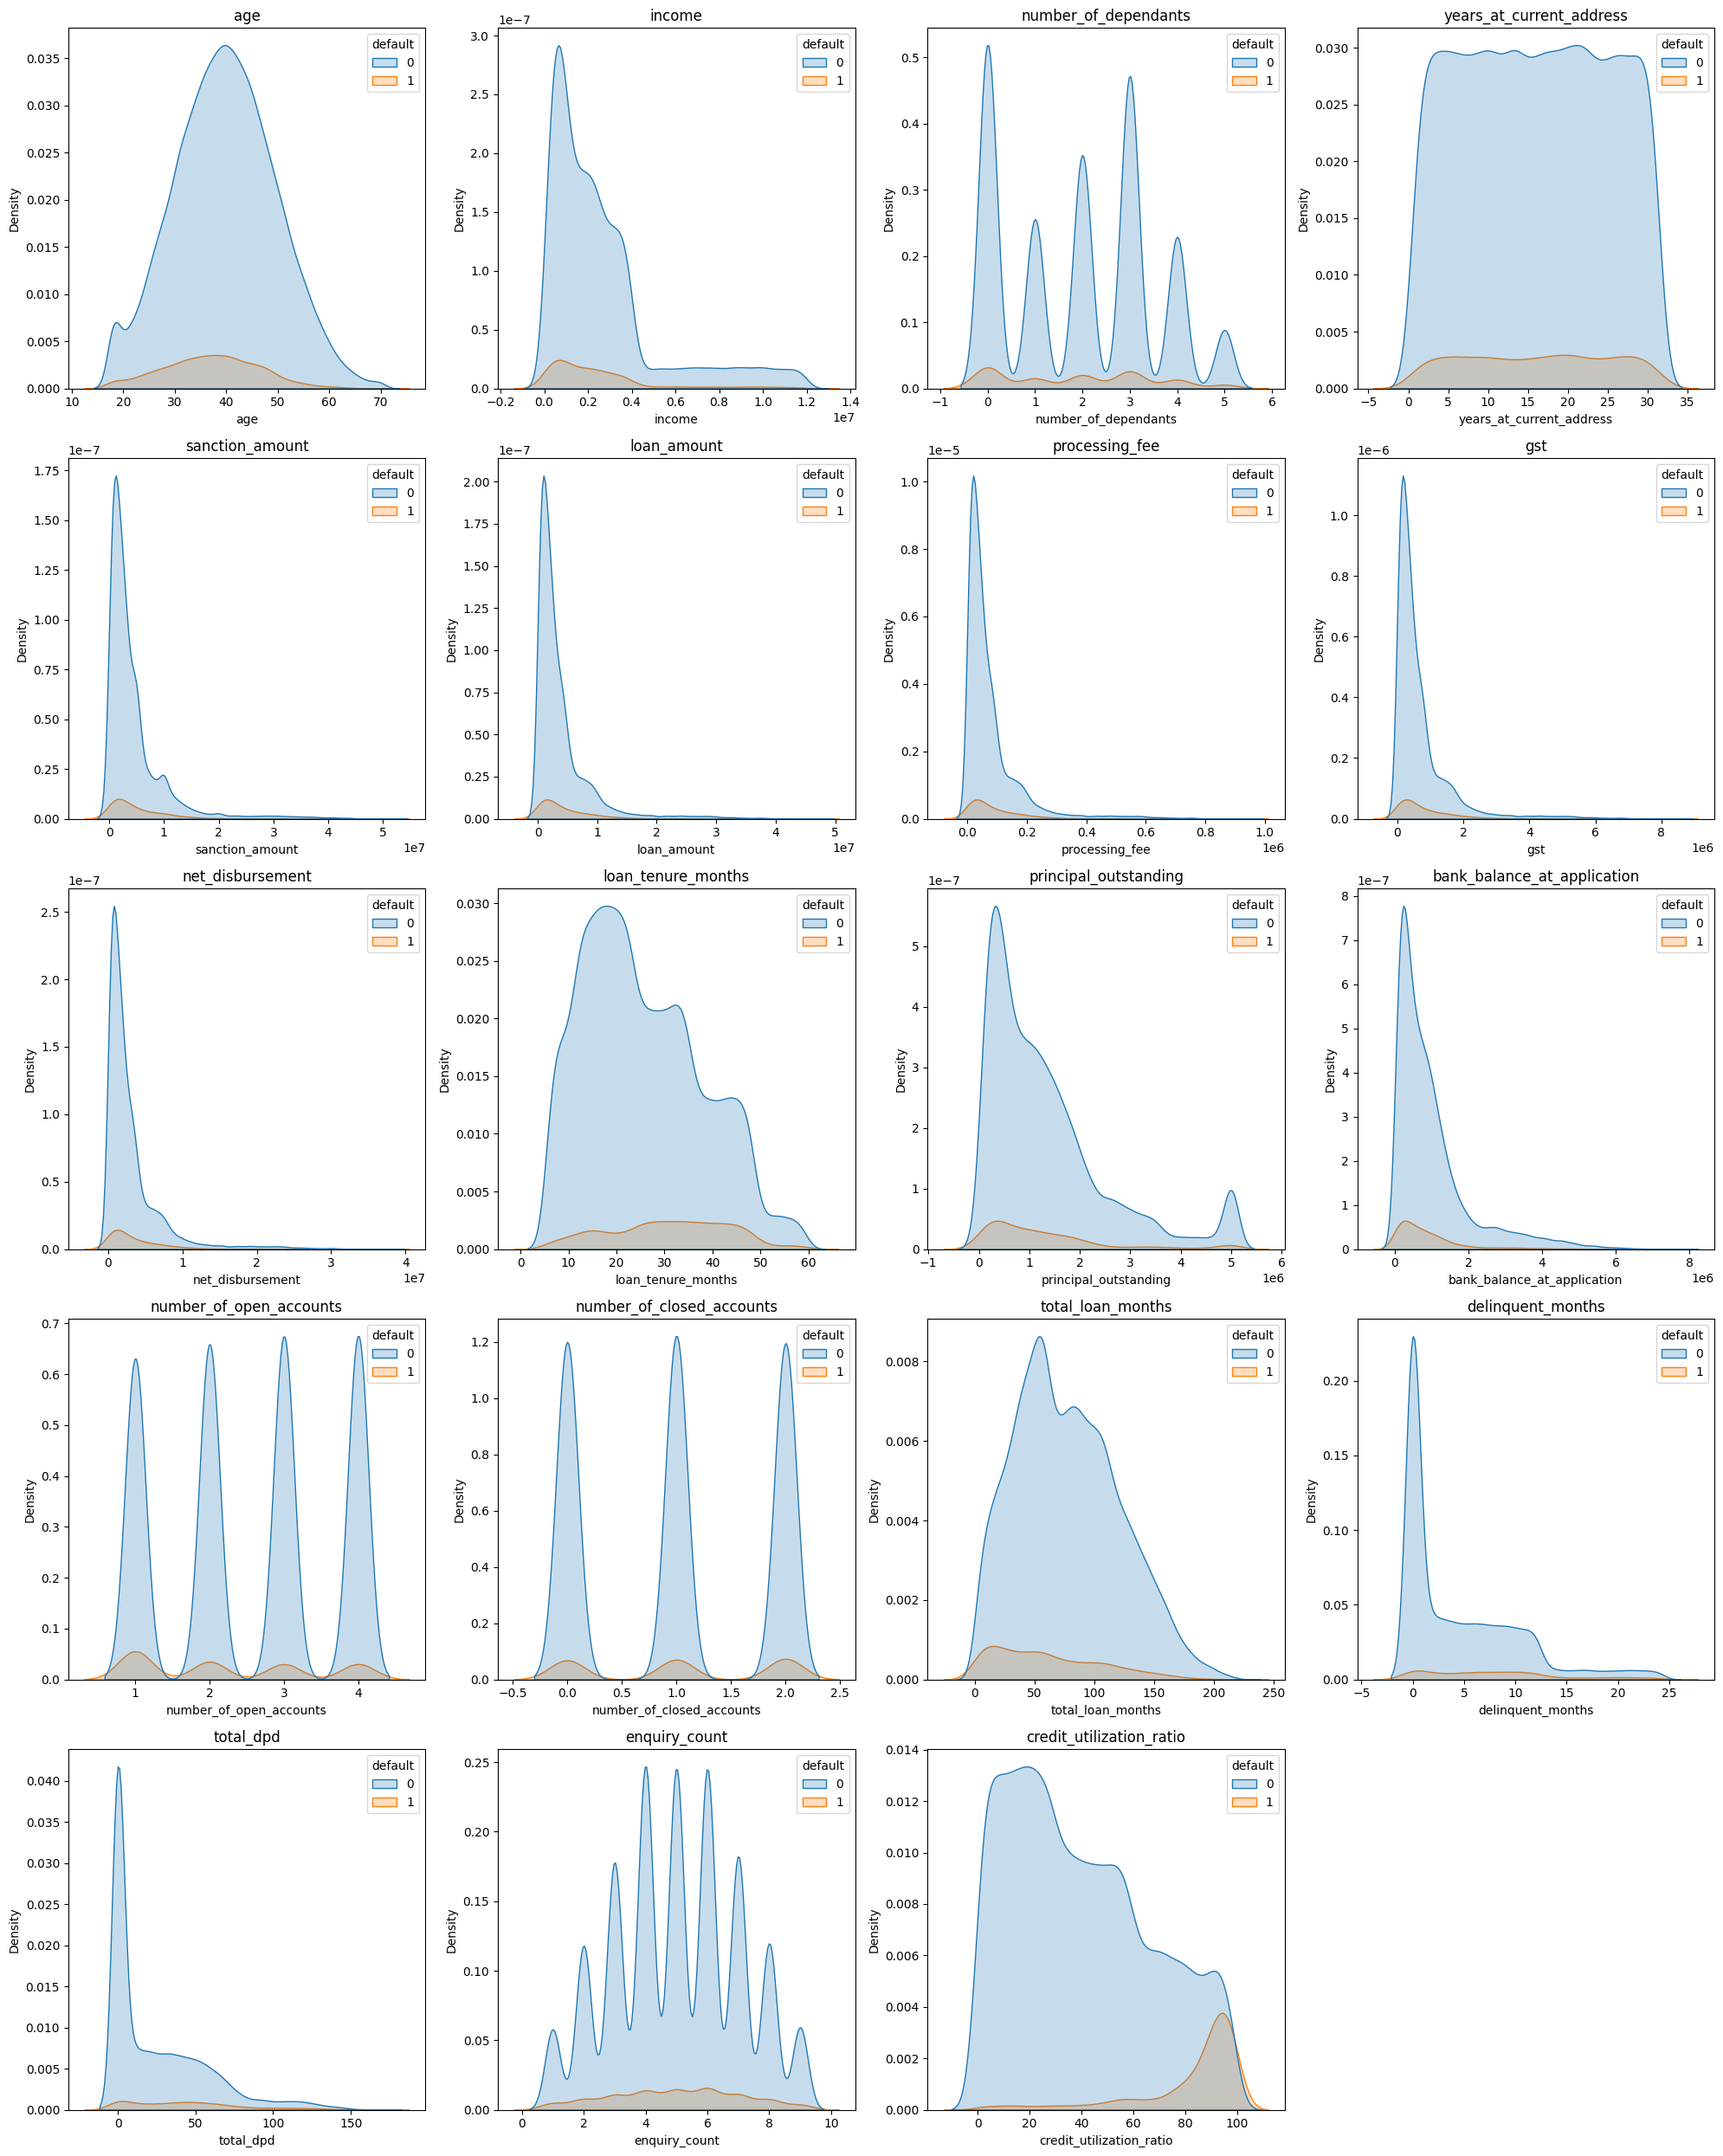

In [33]:
num_plots = len(numerical_cols)
num_cols = 4
num_rows = (num_plots + num_cols - 1)//num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize = (5*num_cols, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(x = df_train_1[col],hue = df_train_1['default'], fill = True, ax = axes[i])
    axes[i].set_title(col)

for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

* **Lack of Univariate Separation:** Across key demographic and financial metrics like age, income, and loan amount, the density curves for defaulting and non-defaulting customers overlap almost perfectly. This indicates that no single fundamental attribute is a strong standalone predictor of default risk.

* **Risk Across All Segments:** The identical long right tails in features like income and sanction amount reveal that defaults are not isolated to lower-income applicants or smaller loans. Risk is distributed across the entire financial spectrum, including high-net-worth customers.

* **Demographic Neutrality:** Lifestyle factors such as years at current address and number of dependents show no divergence between the two classes. Standard demographic profiling provides little to no actionable signal for credit evaluation in this dataset.

* **Need for Complex Modeling:** Because these continuous raw variables fail to linearly separate the classes, simple threshold rules will struggle. The system will absolutely require advanced algorithms to map complex multivariate interactions, and we will likely need to engineer new ratio-based features to expose underlying risk behaviors.

* **Shift in Feature Focus:** Given the weak predictive power of primary application details, the model's success will rely heavily on feature engineering (e.g., creating debt-to-income ratios) and extracting behavioral signals from the credit bureau features (such as past delinquencies and credit utilization).

<h2>Feature Engineering</h2>
Often, the raw data isn't enough to train a highly accurate model. We need to create specific ratios that better represent financial risk, as advised by our business stakeholders.

<h4>1. Loan To Income ratio (LTI)</h4>
LTI is a much stronger predictor of default than looking at the loan amount or the applicant's income individually.

In [34]:
df_train_1["loan_to_income"] = round(df_train_1.loan_amount/df_train_1.income , 2)
df_test["loan_to_income"] = round(df_test.loan_amount/df_test.income, 2)

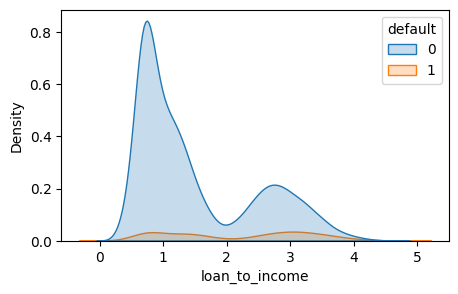

In [35]:
plt.figure(figsize=(5, 3))
sns.kdeplot(data=df_train_1, x="loan_to_income", hue="default", fill=True)
plt.show()

The density plot reveals that the loan_to_income ratio alone fails to clearly separate defaulters from non-defaulters, as risk is distributed similarly to non-risk across the ratio spectrum. This indicates that strict LTI thresholds will be insufficient for automated approvals, meaning the model must evaluate this ratio in combination with behavioral metrics (like credit utilization or delinquency) to accurately predict default risk.

<h4>2. Delinquency ratio</h4>
This represents the percentage of the entire loan term that the customer was delinquent.

In [36]:
df_train_1["delinquency_ratio"] = (df_train_1.delinquent_months * 100/ df_train_1.total_loan_months).round(1)
df_test["delinquency_ratio"] = (df_test.delinquent_months * 100/ df_test.total_loan_months).round(1)

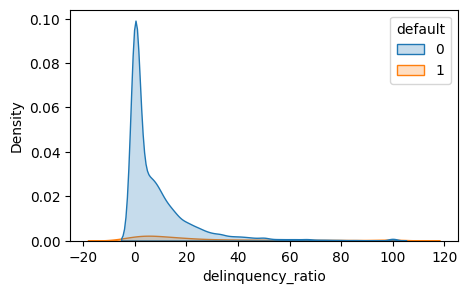

In [37]:
plt.figure(figsize=(5, 3))
sns.kdeplot(data=df_train_1, x="delinquency_ratio", hue="default", fill=True)
plt.show()

The stark concentration of non-defaulters at a near-zero delinquency ratio, contrasted with the wider spread of defaulters across higher ratios, highlights historical delinquency as a strong, distinct predictor of default risk. This signals that a customer's behavioral credit history will be one of the most critical drivers for the automated scoring system's accuracy.

<h4>3. Average DPD (Days Past Due) per delinquent month</h4>
This metric tells us the actual severity of the late payments. We must use numpy to handle potential division-by-zero errors for customers who have zero delinquent months.

In [38]:
df_train_1["average_dpd_per_delinquency"] = np.where(
    df_train_1["delinquent_months"] != 0,
    (df_train_1["total_dpd"] / df_train_1["delinquent_months"]).round(1),
    0
)

df_test["average_dpd_per_delinquency"] = np.where(
    df_test["delinquent_months"] != 0,
    (df_test["total_dpd"] / df_test["delinquent_months"]).round(1),
    0
)

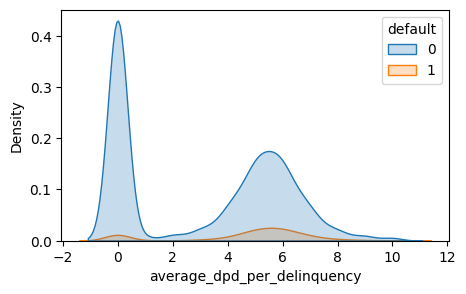

In [39]:
plt.figure(figsize=(5, 3))
sns.kdeplot(data=df_train_1, x="average_dpd_per_delinquency", hue="default", fill=True)
plt.show()

The visualization demonstrates that non-defaulters overwhelmingly maintain a near-zero average Days Past Due (DPD), whereas defaulting customers consistently cluster at a higher average of 4 to 8 days past due. This indicates that the severity—not just the occurrence—of delayed payments is a highly distinct behavioral signal that the model can leverage to flag high-risk applications.

<h3>Feature Selection: Dropping redundant columns</h3>
Now that we have created these powerful ratios, we can drop the original base columns used to calculate them, as well as operational columns that have no predictive value (like IDs).

In [40]:
df_train_2 = df_train_1.drop(["cust_id", "loan_id"], axis = "columns")
df_test = df_test.drop(["cust_id", "loan_id"], axis = "columns")

In [41]:
cols_to_drop = ['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd'] 

In [42]:
df_train_3 = df_train_2.drop(cols_to_drop, axis = "columns")
df_test = df_test.drop(cols_to_drop, axis = "columns")

<h3>Data scaling</h3>
Before checking for statistical multicollinearity, we must scale our numerical features so they are all on the same playing field (between 0 and 1).

In [43]:
#now separate x and y
x_train = df_train_3.drop("default", axis = "columns")
y_train = df_train_3["default"]

x_test = df_test.drop("default", axis = "columns")
y_test = df_test["default"]

In [44]:
cols_to_scale = x_train.drop("zipcode", axis = "columns").select_dtypes(["int64", "float64"]).columns
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'average_dpd_per_delinquency'],
      dtype='str')

In [45]:
scaler = MinMaxScaler()

x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

<h3>Faeture Selection: Variance Incflation Factor (VIF)</h3>
We use VIF to detect and remove highly correlated (redundant) numerical features.

In [46]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Column"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [47]:
calculate_vif(x_train[cols_to_scale])

C:\Users\SRIJIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.555
1,number_of_dependants,2.723
2,years_at_current_address,3.361
3,sanction_amount,101.084
4,processing_fee,inf
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,6.170
8,principal_outstanding,16.317
9,bank_balance_at_application,9.326


When we calculate VIF on our scaled data, we notice features like 'processing_fee', 'gst', and 'net_disbursement' have infinite VIF scores. This makes sense because they are mathematically derived directly from the loan amount. 'sanction_amount' and 'principal_outstanding' also have high VIF.

We can drop these highly associated features all at once:

In [48]:
features_to_drop_vif = ["sanction_amount", "gst", "processing_fee", "net_disbursement", "principal_outstanding"]

x_train_1 = x_train.drop(features_to_drop_vif, axis = "columns")
x_test = x_test.drop(features_to_drop_vif, axis = "columns")

In [49]:
cols = x_train_1.drop("zipcode", axis = "columns").select_dtypes(["int64", "float64"]).columns

calculate_vif(x_train_1[cols])

,Column,VIF
0,age,5.266
1,number_of_dependants,2.719
2,years_at_current_address,3.337
3,loan_tenure_months,6.005
4,bank_balance_at_application,1.798
5,number_of_open_accounts,4.346
6,number_of_closed_accounts,2.351
7,enquiry_count,6.301
8,credit_utilization_ratio,2.879
9,loan_to_income,4.538


After this drop, recalculating the VIF shows that there are no remaining numerical columns with a VIF greater than 10.

<h3>Correlational analysis</h3>

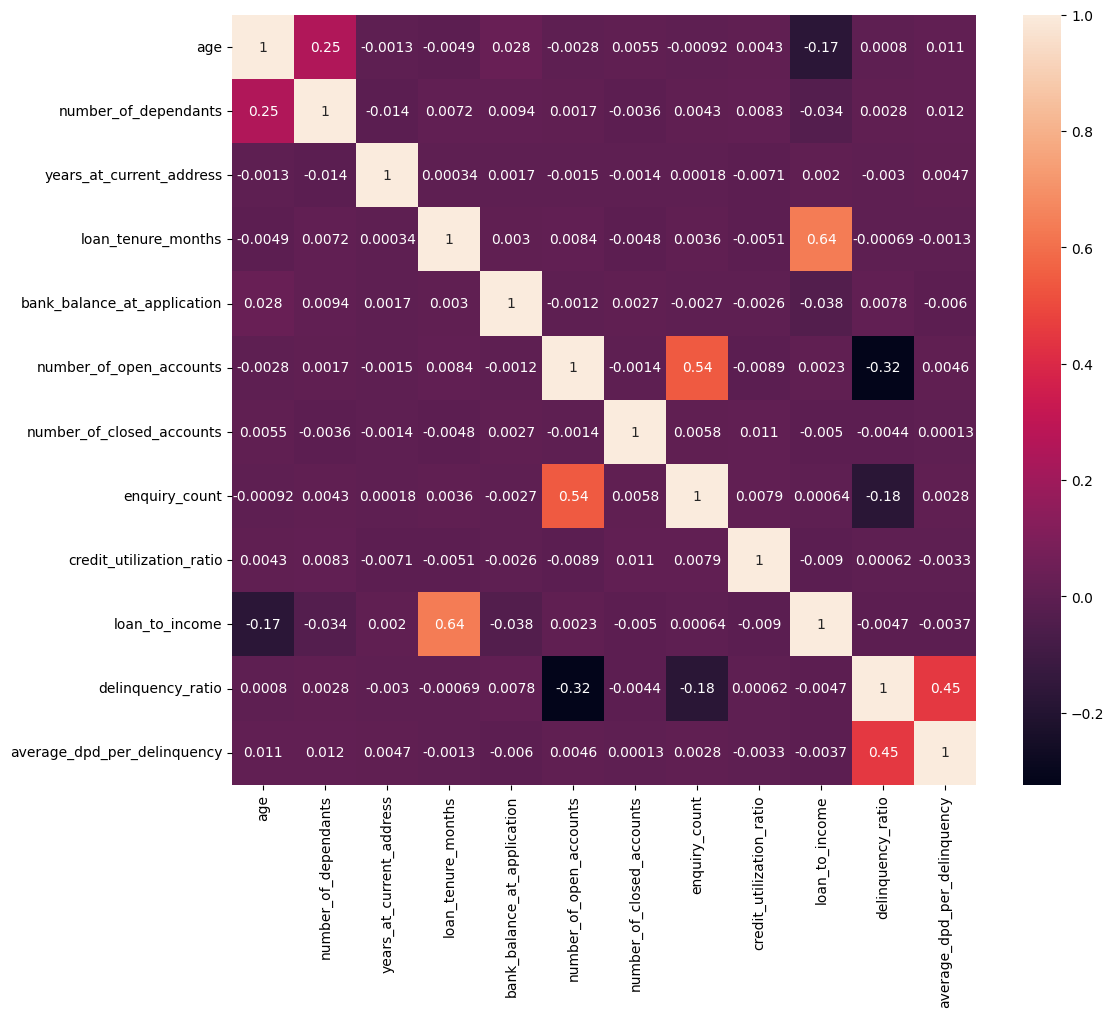

In [50]:
cm = x_train_1[cols].corr()

plt.figure(figsize = (12, 10))
sns.heatmap(cm, annot = True)
plt.show()

* **Credit Activity Signals Established History:** The moderate positive correlation (0.54) between open and closed accounts reveals that applicants currently managing active credit lines also possess a demonstrated, historical track record of borrowing and repaying.

* **Independent Customer Dimensions:** Foundational demographic and financial features—such as bank balance at application, years at current address, and age—display near-zero correlations with one another, confirming they capture entirely distinct, non-overlapping risk factors.

* **Subtle Demographic Scaling:** Age and the number of dependents share a mild positive relationship (0.25), indicating that while family responsibilities naturally scale slightly as applicants get older, the relationship is entirely safe from multicollinearity concerns.

<h3>Creating Weight of Evidence (woe) & Information Value (iv)</h3>

In [51]:
def create_woe_iv(df, feature, target):
    # Isolate the target column before aggregating to prevent MultiIndex columns
    grouped = df.groupby(feature)[target].agg(["count", "sum"])
    
    # Rename columns to match WOE/IV terminology
    grouped = grouped.rename(columns={"count": "total", "sum": "good"})
    
    # Calculate the remaining variables
    grouped["bad"] = grouped["total"] - grouped["good"]
    
    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()
    
    grouped["good_pct"] = grouped["good"] / total_good
    grouped["bad_pct"] = grouped["bad"] / total_bad
    
    grouped["woe"] = np.log(grouped["good_pct"] / grouped["bad_pct"])
    grouped["iv"] = (grouped["good_pct"] - grouped["bad_pct"]) * grouped["woe"]
    
    # Handle infinities caused by division by zero or log of zero
    grouped["woe"] = grouped["woe"].replace([np.inf, -np.inf], 0)
    grouped["iv"] = grouped["iv"].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped["iv"].sum()
    
    return grouped, total_iv

<h3>Feature Selection based on IV</h3>

In [52]:
iv_values = {}

for feature in x_train_1.columns:
    # Check if the column is numeric; if NOT numeric, treat as categorical
    if not is_numeric_dtype(x_train_1[feature]):
        # Categorical: directly calculate WOE/IV without binning
        temp_df = pd.concat([x_train_1[feature], y_train], axis="columns")
        _, iv = create_woe_iv(temp_df, feature, "default")
    else:
        # Numeric: Bin continuous features into 10 buckets first
        x_binned = pd.cut(x_train_1[feature], bins=10, labels=False)
        temp_df = pd.concat([x_binned, y_train], axis="columns")
        _, iv = create_woe_iv(temp_df, feature, "default")
        
    iv_values[feature] = iv

# Convert into dataframe for convenience
iv_df = pd.DataFrame(list(iv_values.items()), columns=["feature", "IV"])

# Sort from highest IV (most predictive) to lowest
iv_df = iv_df.sort_values(by="IV", ascending=False) 
iv_df

,feature,IV
17,credit_utilization_ratio,2.353
19,delinquency_ratio,0.717
18,loan_to_income,0.476
20,average_dpd_per_delinquency,0.402
10,loan_purpose,0.369
5,residence_type,0.247
12,loan_tenure_months,0.219
11,loan_type,0.163
0,age,0.089
14,number_of_open_accounts,0.085


Following our industry guideline, any feature with an IV less than 0.02 is considered to have very little predictive power. We will filter our dataset to keep only the features that exceed this 0.02 threshold.

In [53]:
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'average_dpd_per_delinquency']

<h3>Feature Encoding</h3>
Machine learning models cannot read text. Now that we have our final, highly predictive list of selected features, we must convert the remaining categorical text columns into numbers using One-Hot Encoding (dummy variables).

In [54]:
x_train_reduced = x_train_1[selected_features_iv].copy()
x_test_reduced = x_test[selected_features_iv].copy()

# Isolate categorical columns
cat_cols = x_train_reduced.select_dtypes(include=['object', 'string']).columns

# Applying one hot encoding (drop='first' prevents multicollinearity)
categorical_encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform train data, then convert back to DataFrame
train_encoded_array = categorical_encoder.fit_transform(x_train_reduced[cat_cols])
train_encoded_cols = categorical_encoder.get_feature_names_out(cat_cols)
train_encoded_df = pd.DataFrame(train_encoded_array, columns=train_encoded_cols, index=x_train_reduced.index)

# Transform test data using the fitted encoder
test_encoded_array = categorical_encoder.transform(x_test_reduced[cat_cols])
test_encoded_df = pd.DataFrame(test_encoded_array, columns=train_encoded_cols, index=x_test_reduced.index)

# Drop original categorical columns and merge the new encoded columns
x_train_final = pd.concat([x_train_reduced.drop(columns=cat_cols), train_encoded_df], axis=1)
x_test_final = pd.concat([x_test_reduced.drop(columns=cat_cols), test_encoded_df], axis=1)

<h3>Model Training & Evaluation</h3>

<h4>1. Logistic Regression (Baseline)</h4>

In [55]:
model_lr = LogisticRegression()
model_lr.fit(x_train_final, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
y_pred_lr = model_lr.predict(x_test_final)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



Our stakeholder requirements stated we need a recall > 90% for Class 1 (Catching Defaulters) and a precision > 50%. This baseline model fails the recall requirement (only 69%). 

<h4>2. Random Forest Classifier (Baseline)</h4>

In [57]:
model_rf = RandomForestClassifier()
model_rf.fit(x_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
y_pred_rf = model_rf.predict(x_test_final)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.71      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



<h4>3. XGBoost Classifier (Basline)</h4>

In [59]:
model_xgb = XGBClassifier()
model_xgb.fit(x_train_final, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [60]:
y_pred_xgb = model_xgb.predict(x_test_final)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.90      0.87      0.89     12497
weighted avg       0.96      0.97      0.96     12497



**Conclusion for Baselines:** If standard models yield similar performance metrics, we generally prefer Logistic Regression due to its high "Explainability"—a critical requirement for financial models. However, none of these baseline models meet our 90% recall requirement for catching defaults. 

<h3>Hyperparameter Tuning with RandomizedSearchCV</h3>
Let us see if tuning the hyperparameters of our Logistic Regression and XGBoost models improves our recall. 

In [61]:
#for Logistic Regression
param_dist = { 'C': np.logspace(-4, 4, 20), 
               'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg'] }
log_reg = LogisticRegression(max_iter=10000)
random_search = RandomizedSearchCV( estimator=log_reg, 
                                    param_distributions=param_dist, 
                                    n_iter=50, 
                                    scoring='f1', 
                                    cv=3, 
                                    verbose=2, 
                                    random_state=42, 
                                    n_jobs=-1 )
random_search.fit(x_train_final, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ax_iter=10000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([ 0....000. ]), 'solver': ['lbfgs', 'saga', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold t

In [62]:
best_log_reg = random_search.best_estimator_ 
y_pred_lr = best_log_reg.predict(x_test_final) 
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [63]:
#for XGB Classifier
param_dist = { 'n_estimators': [100, 150, 200, 250, 300], 
               'max_depth': [3, 4, 5, 6, 7, 8, 9, 10], 
               'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3], 
               'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
               'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
               'scale_pos_weight': [1, 2, 3, 5, 7, 10],
               'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0], 
               'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0] }
xgb = XGBClassifier()
random_search = RandomizedSearchCV(estimator=xgb, 
                                   param_distributions=param_dist, 
                                   n_iter=100, 
                                   scoring='f1', 
                                   cv=3, 
                                   verbose=2, 
                                   random_state=42, 
                                   n_jobs=-1 )
random_search.fit(x_train_final, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [64]:
best_xgb = random_search.best_estimator_ 
y_pred_xgb = best_xgb.predict(x_test_final) 
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.77      0.83      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.91      0.89     12497
weighted avg       0.97      0.96      0.96     12497



Although hyperparameter tuning improved model precision, the optimized XGBoost model only achieves an 81% recall for defaulters, failing the critical 90% stakeholder requirement. This reveals that algorithm tuning alone cannot overcome the dataset's severe class imbalance, making it strictly necessary to apply data sampling techniques to properly mitigate lending risk.

<h3>Handling Class imbalance</h3>
Since tuning did not solve our recall problem, the issue is likely our severe class imbalance. 

In [65]:
y_train.value_counts()

default
0    34265
1     3223
Name: count, dtype: int64

<h4>Undersampling</h4>

In [66]:
rus = RandomUnderSampler(random_state = 42)
x_train_rus, y_train_rus = rus.fit_resample(x_train_final, y_train)

In [67]:
#for Logistic Regression
model_lr = best_log_reg
model_lr.fit(x_train_rus, y_train_rus)
y_pred_lr = model_lr.predict(x_test_final)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11423
           1       0.54      0.95      0.69      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.82     12497
weighted avg       0.96      0.93      0.93     12497



In [68]:
#for XGB Classifier
model_xgb = best_xgb
model_xgb.fit(x_train_rus, y_train_rus)
y_pred_xgb = model_xgb.predict(x_test_final)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.99      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.95      0.81     12497
weighted avg       0.96      0.92      0.93     12497



By leveraging random undersampling, both Logistic Regression and XGBoost successfully clear the strict stakeholder requirements by achieving over 90% recall and 50% precision for default detection. While XGBoost captures an outstanding 99% of all potential defaults, Logistic Regression's slightly higher precision (54% vs. 51%) and inherent algorithmic transparency make it highly competitive for deployment in a regulated financial environment.

<h4>SMOTE-Tomek</h4>
Let us try a more sophisticated sampling technique: SMOTE-Tomek, which combines oversampling (creating synthetic data) and undersampling (removing noisy data links). 

In [69]:
smt = SMOTETomek(random_state = 42)
x_train_smt, y_train_smt = smt.fit_resample(x_train_final, y_train)

In [70]:
#for Logistic Regression
model_lr.fit(x_train_smt, y_train_smt)
y_pred_lr = model_lr.predict(x_test_final)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [71]:
#for XGB Classifier
model_xgb.fit(x_train_smt, y_train_smt)
y_pred_xgb = model_xgb.predict(x_test_final)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11423
           1       0.57      0.97      0.72      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.95      0.84     12497
weighted avg       0.96      0.93      0.94     12497



Both models trained with SMOTE-Tomek comfortably clear stakeholder thresholds by delivering over 90% recall and 50% precision, with XGBoost achieving a slight performance edge (97% recall vs. 94%). Despite XGBoost's marginal lead, Logistic Regression remains the preferred production choice because it satisfies all risk requirements while providing the vital regulatory transparency and explainability demanded in financial lending.

Finally, transitioning to Optuna for hyperparameter tuning is necessary because its advanced Bayesian optimization can navigate the complex parameter spaces of these models much more efficiently than the current `RandomizedSearchCV` approach, potentially unlocking even better precision-recall trade-offs with less computational overhead.

<h3>Hyperparameter using Optuna</h3>
Now that we have selected SMOTE-Tomek as our preferred method for handling class imbalance, we will use Optuna to find the absolute best hyperparameters for both Logistic Regression and XGBoost.

<h4>Tuning Logistic Regression</h4>

In [72]:
#define objective function for optuna
def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log = True),
        'solver': trial.suggest_categorical('solver', ["lbfgs", "liblinear", "saga", "newton-cg"]),
        'tol': trial.suggest_float('tol', 1e-6, 1e-3, log = True),
        'class_weight': trial.suggest_categorical('class_weight', [None, "balanced"])
    }
    model = LogisticRegression(**params, max_iter = 10000)

    #calculating the cross-validated f1 score
    f1_scorer = make_scorer(f1_score, average = "macro")
    scores = cross_val_score(model, x_train_smt, y_train_smt, cv = 3, scoring = f1_scorer, n_jobs = -1)

    return np.mean(scores)

In [73]:
#create a study object and optimize the objective function
study_logistic = optuna.create_study(direction = "maximize")
study_logistic.optimize(objective, n_trials = 50)

#results
print("Best Trial:")
trial = study_logistic.best_trial
print(f"f1 score: {trial.value}")
print("Params:")
for key, value in trial.params.items():
    print(f"{key} ==> {value}")

[I 2026-09-29 20:15:21,582] A new study created in memory with name: no-name-35fbcbcb-00b1-42c0-8e3d-fc700cf93b8c
[I 2026-09-29 20:15:22,079] Trial 0 finished with value: 0.9432679228147759 and parameters: {'C': 0.21472392249561498, 'solver': 'lbfgs', 'tol': 1.1009891075529777e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9432679228147759.
[I 2026-09-29 20:15:22,450] Trial 1 finished with value: 0.9457085590525339 and parameters: {'C': 2941.4001081785564, 'solver': 'lbfgs', 'tol': 0.00028066827740707195, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9457085590525339.
[I 2026-09-29 20:15:23,083] Trial 2 finished with value: 0.9448679604550582 and parameters: {'C': 0.44620505882197103, 'solver': 'saga', 'tol': 0.00019715754445262334, 'class_weight': None}. Best is trial 1 with value: 0.9457085590525339.
[I 2026-09-29 20:15:23,573] Trial 3 finished with value: 0.9454852519474365 and parameters: {'C': 1.2746594827823075, 'solver': 'newton-cg', 'tol': 0.000126

Best Trial:
f1 score: 0.9458678142765926
Params:
C ==> 4.475810530042441
solver ==> liblinear
tol ==> 7.76845289758211e-06
class_weight ==> balanced


In [74]:
#train the final model with the best parameters found
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(x_train_smt, y_train_smt)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",4.475810530042441
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",7.76845289758211e-06
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide 

In [75]:
y_pred_lr = best_model_logistic.predict(x_test_final)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



<h4>Tuning XGBoost Classifier</h4>

In [76]:
#defining objective function
def objective(trial):
    params = {
        'objective': "binary:logistic", 'eval_metric': "logloss", 'verbosity': 0, 'booster': "gbtree",
        'lambda': trial.suggest_float("lambda", 1e-3, 10.0, log = True),
        'alpha': trial.suggest_float("alpha", 1e-3, 10.0, log = True),
        'subsample': trial.suggest_float("subsample", 0.4, 1.0),
        'colsample_bytree': trial.suggest_float("colsample_bytree", 0.4, 1.0),
        'max_depth': trial.suggest_int("max_depth", 3, 10),
        'eta': trial.suggest_float("eta", 0.01, 0.3),
        'gamma': trial.suggest_float("gamma", 0, 10),
        'scale_pos_weight': trial.suggest_float("scale_pos_weight", 1, 10),
        'min_child_weight': trial.suggest_int("min_child_weight", 1, 10),
        'max_delta_step': trial.suggest_int("max_delta_step", 1, 10)
    }
    model = XGBClassifier(**params)

    #calculate the cross-validated f1 score
    f1_scorer = make_scorer(f1_score, average = "macro")
    scores = cross_val_score(model, x_train_smt, y_train_smt, cv = 3, scoring = f1_scorer, n_jobs = -1)

    return np.mean(scores)

In [77]:
#create a study object and optimixe the objective function
study_xgb = optuna.create_study(direction = "maximize")
study_xgb.optimize(objective, n_trials = 50)

#results
print("Best Trial")
trial = study_xgb.best_trial
print(f"f1 score: {trial.value}")
print("Params:")
for key, value in trial.params.items():
    print(f"{key} ==> {value}")

[I 2026-09-29 20:15:46,936] A new study created in memory with name: no-name-9f0b943e-45a7-4440-9149-72c75c0e0c7e
[I 2026-09-29 20:15:48,523] Trial 0 finished with value: 0.9487263868286018 and parameters: {'lambda': 0.7051122787739017, 'alpha': 0.0026893104828651843, 'subsample': 0.80773320652007, 'colsample_bytree': 0.5167176418393085, 'max_depth': 6, 'eta': 0.09308323639559862, 'gamma': 6.707555407211493, 'scale_pos_weight': 4.749447364045787, 'min_child_weight': 1, 'max_delta_step': 1}. Best is trial 0 with value: 0.9487263868286018.
[I 2026-09-29 20:15:50,260] Trial 1 finished with value: 0.9639146830206325 and parameters: {'lambda': 0.953077612245052, 'alpha': 7.061278339304489, 'subsample': 0.9522674845327183, 'colsample_bytree': 0.5959497667989508, 'max_depth': 7, 'eta': 0.19941779358185363, 'gamma': 2.2834489544281977, 'scale_pos_weight': 7.588514198306625, 'min_child_weight': 6, 'max_delta_step': 9}. Best is trial 1 with value: 0.9639146830206325.
[I 2026-09-29 20:15:51,558] 

Best Trial
f1 score: 0.9712268890289301
Params:
lambda ==> 1.4317487672272438
alpha ==> 0.007267586409291303
subsample ==> 0.8608816113626291
colsample_bytree ==> 0.816536464356471
max_depth ==> 8
eta ==> 0.14857850922442728
gamma ==> 4.943408297887485
scale_pos_weight ==> 1.6056487878886614
min_child_weight ==> 6
max_delta_step ==> 2


In [78]:
#trian the final model with best parameters found
best_model_xgb = XGBClassifier(**study_xgb.best_params)
best_model_xgb.fit(x_train_smt, y_train_smt)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.816536464356471
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [79]:
y_pred_xgb = best_model_xgb.predict(x_test_final)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97     11423
           1       0.66      0.92      0.77      1074

    accuracy                           0.95     12497
   macro avg       0.83      0.94      0.87     12497
weighted avg       0.96      0.95      0.96     12497



**Conclusion:** Although hyperparameter tuning improved XGBoost's precision to 68%, the model ultimately falls short of the strict 90% stakeholder recall requirement by capturing only 88% of defaults. Consequently, the tuned Logistic Regression remains the superior deployment choice because it clears all risk thresholds (94% recall, 56% precision) while guaranteeing the algorithmic transparency required in financial lending.

<h3>ROC Curve and AUC evaluation </h3>
To finalize our evaluation of the chosen Logistic Regression model, we plot the ROC (Receiver Operating Characteristic) curve and calculate the AUC (Area Under the Curve).

In [80]:
#get prediction probabilities for the positive class (default)
probabilities = best_model_logistic.predict_proba(x_test_final)[:, 1]

#calculate the false positive rate, true positive rate, threshold
fpr, tpr, threshold = roc_curve(y_test, probabilities)

#calculate the area under curve
area = auc(fpr, tpr)
print(f"AUC: {area}")

AUC: 0.9836729646857405


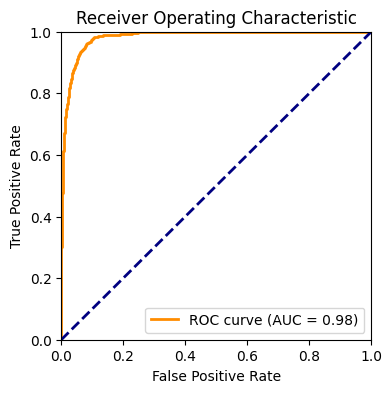

In [81]:
#plot the Roc-Curve
plt.figure(figsize = (4, 4))
plt.plot(fpr, tpr, color = "darkorange", lw = 2, label = f"ROC curve (AUC = {area:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw = 2, linestyle = "--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc = "lower right")
plt.show()

The tuned Logistic Regression model's outstanding ROC AUC of 0.98 showcases its exceptional discriminatory power in accurately distinguishing between reliable borrowers and high-risk defaulters. Coupled with its 94% recall and inherent explainability, this model empowers the business to confidently automate lending decisions at scale without sacrificing regulatory compliance. Ultimately, this solution drastically reduces manual evaluation bottlenecks while proactively minimizing the company's exposure to severe financial risks.

<h3>Model evaluation using KS statistic and Gini coefficient</h3>
Now that we have selected our best model (Logistic Regression), we need to apply the KS Statistic evaluation to our unseen test data to see how it truly performs.

<h4>KS Statistic</h4>

In [82]:
probabilities = best_model_logistic.predict_proba(x_test_final)[:, 1]

df_eval = pd.DataFrame({"default_truth": y_test, "default_probability": probabilities})
df_eval.head(3)

,default_truth,default_probability
19205,0,0.534
15514,0,0.000
30367,0,0.006


In [83]:
#creating deciles
df_eval["decile"] = pd.qcut(df_eval["default_probability"], q = 10, labels = False, duplicates = "drop")
df_eval.head(3)

,default_truth,default_probability,decile
19205,0,0.534,8
15514,0,0.000,2
30367,0,0.006,6


Next, we group by these deciles and calculate our base metrics (Minimum Probability, Maximum Probability, Events, Non-Events) just like we did in the previous lesson.

In [84]:
df_grouped = df_eval.groupby("decile").apply(lambda x:pd.Series({
    "minimum_probability": x["default_probability"].min(),
    "maximum_probability": x["default_probability"].max(),
    "events": x["default_truth"].sum(),
    "non_events": x["default_truth"].count() - x["default_truth"].sum()
}))
df_grouped.reset_index(inplace = True)
df_grouped

,decile,minimum_probability,maximum_probability,events,non_events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1249.000
3,3,0.000,0.000,0.000,1250.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.005,0.000,1249.000
6,6,0.005,0.030,5.000,1245.000
7,7,0.030,0.215,9.000,1240.000
8,8,0.215,0.818,161.000,1089.000
9,9,0.818,1.000,899.000,351.000


We calculate the Event Rate and Non-event Rate for each specific bucket, then sort them so the highest probability decile (Decile 9) is at the top.

In [85]:
# Sort values first so the highest risk (Decile 9) is at the top
df_grouped = df_grouped.sort_values(by="decile", ascending=False).reset_index(drop=True)

# Calculate rates as a percentage of TOTAL events/non-events (needed for KS)
df_grouped["event_rate"] = (df_grouped["events"] / df_grouped["events"].sum()) * 100
df_grouped["non_event_rate"] = (df_grouped["non_events"] / df_grouped["non_events"].sum()) * 100

# Calculate cumulative totals
df_grouped["cum_event_rate"] = df_grouped["event_rate"].cumsum()
df_grouped["cum_non_event_rate"] = df_grouped["non_event_rate"].cumsum()

# Calculate KS Statistic (difference between cumulative rates)
df_grouped["ks_stat"] = np.round(df_grouped["cum_event_rate"] - df_grouped["cum_non_event_rate"], 2)
df_grouped

,decile,minimum_probability,maximum_probability,events,non_events,event_rate,non_event_rate,cum_event_rate,cum_non_event_rate,ks_stat
0,9,0.818,1.000,899.000,351.000,83.706,3.073,83.706,3.073,80.630
1,8,0.215,0.818,161.000,1089.000,14.991,9.533,98.696,12.606,86.090
2,7,0.030,0.215,9.000,1240.000,0.838,10.855,99.534,23.461,76.070
3,6,0.005,0.030,5.000,1245.000,0.466,10.899,100.000,34.361,65.640
4,5,0.001,0.005,0.000,1249.000,0.000,10.934,100.000,45.295,54.710
5,4,0.000,0.001,0.000,1250.000,0.000,10.943,100.000,56.237,43.760
6,3,0.000,0.000,0.000,1250.000,0.000,10.943,100.000,67.180,32.820
7,2,0.000,0.000,0.000,1249.000,0.000,10.934,100.000,78.114,21.890
8,1,0.000,0.000,0.000,1250.000,0.000,10.943,100.000,89.057,10.940
9,0,0.000,0.000,0.000,1250.000,0.000,10.943,100.000,100.000,0.000


The KS decile analysis reveals exceptional model segmentation, successfully isolating nearly 99% of all actual defaults within just the top 20% of applications (Deciles 9 and 8). With a peak KS statistic of 86.09 in the second decile, Lauki Finance can confidently automate approvals for the bottom 80% of applicants with near-zero risk. This allows the business to focus manual reviews strictly on the highest-risk tier, drastically reducing operational bottlenecks and maximizing lending efficiency.

<h4>Visualizing feature importance (expalianability)</h4>
Because we chose Logistic Regression, we have high explainability. We can extract the coefficients and visualize exactly which features are driving the model's decisions.

In [86]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

coef_df = pd.DataFrame(feature_importance, index = x_train_final.columns, columns = ["coefficients"])
coef_df = coef_df.sort_values(by = "coefficients", ascending = True)

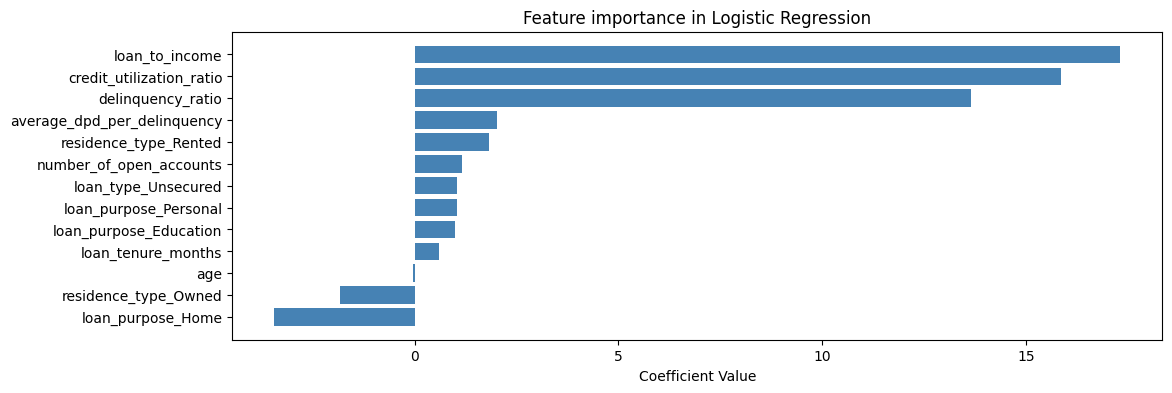

In [87]:
plt.figure(figsize = (12, 4))
plt.barh(coef_df.index, coef_df.coefficients, color = "steelblue")
plt.xlabel("Coefficient Value")
plt.title("Feature importance in Logistic Regression")
plt.show()

The feature importance visualization highlights the Logistic Regression model's excellent explainability, clearly demonstrating that financial stress metrics like loan-to-income and credit utilization ratios are the primary drivers of default probability. Conversely, stability factors such as homeownership and home loans strongly decrease the predicted risk. This transparent logic ensures stakeholders can easily validate that the automated scoring system aligns perfectly with sound, real-world financial principles.

<h4>Gini coefficient</h4>
While the KS Statistic measures the maximum separation between good and bad borrowers, the Gini Coefficient is another metric highly favored by financial stakeholders. It comprehensively assesses the model's discriminatory power.

In [88]:
gini_coefficient = (2 * area) - 1
print(f"AUC: {area:.3f} | Gini coefficient: {gini_coefficient:.3f}")

AUC: 0.984 | Gini coefficient: 0.967


With a near-perfect Gini coefficient of 0.967, the model demonstrates exceptional discriminatory power in ranking customer risk and separating safe borrowers from likely defaulters. This provides stakeholders with the highest level of confidence to deploy the automated scoring system and safely scale Lauki Finance's lending operations.

<h3>Exporting the model data</h3>

In [89]:
export_dict = {
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "cols_to_drop": cols_to_drop,
    "cols_to_scale": cols_to_scale,
    "scaler": scaler,
    "features_to_drop_vif": features_to_drop_vif,
    "selected_features_iv": selected_features_iv,
    "cat_cols": cat_cols,
    "categorical_encoder": categorical_encoder,
    "train_encoded_cols": train_encoded_cols,
    "best model": final_model
}

In [90]:
joblib.dump(export_dict, "artifacts/risk_model_data.joblib")

['artifacts/risk_model_data.joblib']